## **HR Attrition Prediction 코드 설명**
- 목적: 현재 상태를 바탕으로 직원이 이직할 확률을 예측하는 모델링을 구현하기 위함
- 사용된 데이터: 임직원의 특징과 이직 여부를 포함한 데이터 (*이직 구분자: Attrition)

In [2]:
import pandas as pd
from sqlalchemy import create_engine, text
from scipy.stats import chi2_contingency, ttest_ind

# Localhost MySQL 연결 
USER = "root"
PASSWORD = "!h131417p"
HOST = "127.0.0.1"
PORT = "3306"
DB = "hr"

engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}")

In [4]:
# SQL 결과 확인 함수
def run_query(query):
    return pd.read_sql(text(query), engine)

### 1. 데이터 가져오기

In [6]:
# MySQL에 있는 DB에서 데이터 가져오기
query_model = """
SELECT *
FROM hr_employee_attrition;
"""
df = run_query(query_model)

### 2. 데이터 전처리

In [77]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# target 변환
df_model["Attrition"] = df_model["Attrition"].map({"Yes":1, "No":0})

# 범주형 처리
'''
for col in df_model.select_dtypes(include="object").columns:
    if col != "Attrition":
        df_model[col] = LabelEncoder().fit_transform(df_model[col])
'''

encoders = {}

for col in df_model.select_dtypes(include="object").columns:
    if col != "Attrition":
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col])
        encoders[col] = le

### 3. 학습용 / 테스트용 데이터 분리

In [80]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4. 모델 학습 (Logistic)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [85]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### 5. 성능 평가

In [88]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5884353741496599
ROC-AUC: 0.5755656108597286


C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### 변수 중요도 확인

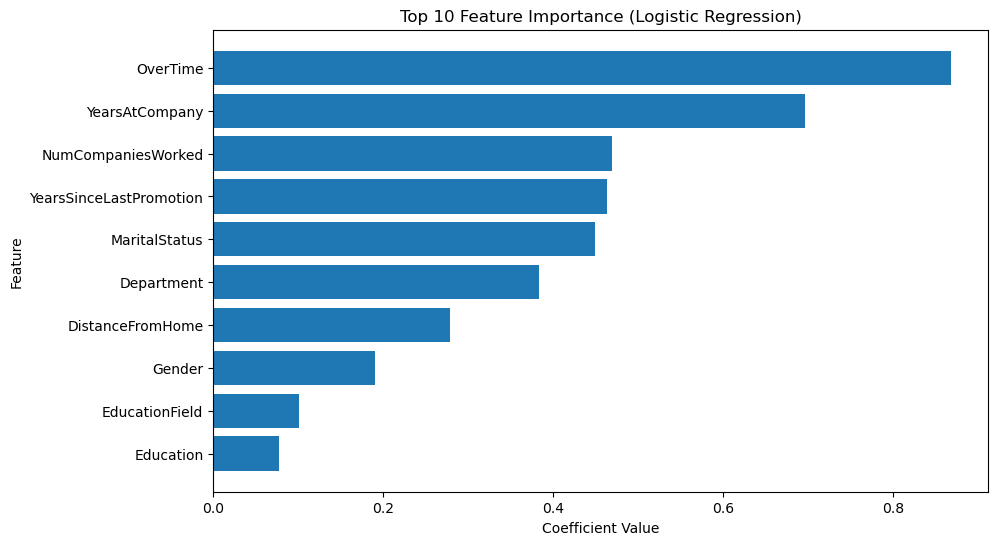

In [102]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0]
}).sort_values(by="coef", ascending=False)

# 변수 중요도 상위 10개 추출 
top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["feature"], top10["coef"])

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Logistic Regression)")

plt.gca().invert_yaxis()  # 중요도 높은 게 위로

plt.show()

### 잔류자 중 이직 리스크 직원 찾기

In [94]:
# 잔류자 데이터만 가져오는 쿼리 
query_active = """
SELECT *
FROM hr_employee_attrition
WHERE Attrition = 'No';
"""
df_active = run_query(query_active)
df_active.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
1,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
2,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
3,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
4,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0


In [96]:
# 전처리 과정
df_active_model = df_active.copy()

for col, le in encoders.items():
    df_active_model[col] = le.transform(df_active_model[col])

X_active = df_active_model.drop("Attrition", axis=1)

X_active_scaled = scaler.transform(X_active)

In [98]:
# 기존에 학습된 모델로 잔류자 데이터 예측
active_prob = model.predict_proba(X_active_scaled)[:,1]

# 이직할 확률 컬럼 생성 
df_active["attrition_prob"] = active_prob

# 이직 위험도 높은 순으로 확인
df_active_risk = df_active.sort_values("attrition_prob", ascending=False)
df_active_risk.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,attrition_prob
567,33,No,Travel_Rarely,1198,Research & Development,1,4,Other,1,939,...,80,0,6,1,3,3,2,0,2,0.809117
901,50,No,Travel_Frequently,333,Research & Development,22,5,Medical,1,1539,...,80,0,32,2,3,32,6,13,9,0.799633
792,41,No,Non-Travel,256,Sales,10,2,Medical,1,1329,...,80,0,19,4,3,19,2,11,9,0.788591
947,22,No,Non-Travel,457,Research & Development,26,2,Other,1,1605,...,80,0,4,2,2,4,2,1,3,0.764743
1204,21,No,Travel_Rarely,501,Sales,5,1,Medical,1,2021,...,80,0,2,6,3,2,2,1,2,0.738758
29,36,No,Travel_Rarely,852,Research & Development,5,4,Life Sciences,1,51,...,80,1,6,3,4,1,1,0,0,0.720208
240,26,No,Travel_Frequently,496,Research & Development,11,2,Medical,1,390,...,80,1,5,3,3,5,3,3,3,0.714445
41,26,No,Travel_Rarely,1443,Sales,23,3,Marketing,1,72,...,80,1,5,2,2,2,2,0,0,0.698388
474,38,No,Travel_Rarely,268,Research & Development,2,5,Medical,1,773,...,80,1,6,0,1,1,0,0,1,0.693753
1073,46,No,Non-Travel,849,Sales,26,2,Life Sciences,1,1801,...,80,0,6,3,3,2,2,2,2,0.651354


In [100]:
df_active_risk.to_csv('C:/Users/user/Desktop/HR/HR_prediction.csv')